In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import least_squares
import statsmodels.stats.diagnostic as smd
import glob
from io import StringIO

In [2]:
def data_wrangling(data_folder):
    all_dfs = []
    files = glob.glob(os.path.join(data_folder, '*.csv'))
    print(f" Found {len(files)} CSV files in {data_folder}\n")

    for file_path in files:
        try:
            # Try reading file with UTF-8, fallback to UTF-8-SIG
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
            except UnicodeDecodeError:
                with open(file_path, 'r', encoding='utf-8-sig') as f:
                    lines = f.readlines()
            # Skip 2 header lines after first
            if len(lines) < 4:
                print(f" File too short to process: {file_path}")
                continue
            df = pd.read_csv(StringIO(''.join(lines)))
            df = df.dropna(subset=["trlno"]).copy()
            # remove practice trials
            df = df[df['stochasticity'].isin(['low', 'high'])]

            df = df.sort_values(by='trlno').reset_index(drop=True)
            df['blkNo'] = ((df['trlno'] - 16) // 50) + 1  # First 15 trials are practice
            df = df[df['trlno'] > 15]

            df['sub'] = df['participant']
            df["trlNo"] = df["trlno"].astype(int)
            df["stim_duration"] = pd.to_numeric(df["stim_duration"], errors="coerce")
            df["rpr_duration"] = pd.to_numeric(df["rpr_duration"], errors="coerce")
            # calculate error
            df['rep_err'] = df['rpr_duration'] - df['stim_duration']

            df["prev_stochasticity"] = df["stochasticity"].shift(50)
            # add a new column preErr, indicating the previous trial's error
            df['preErr'] = df.groupby(['sub', 'stochasticity'])['rep_err'].shift(1)
            # add a new column preDuration, the duration of the previous visual stimulus
            df['preDuration'] = df.groupby(['sub', 'stochasticity'])['stim_duration'].shift(1)
            block_stoch = df.groupby(['sub', 'blkNo'])['stochasticity'].first().reset_index()
            block_stoch['prev_stochasticity'] = block_stoch.groupby('sub')['stochasticity'].shift(1)
            block_stoch['block_transition'] = block_stoch['prev_stochasticity'].str[0].str.upper().fillna('S') + \
                                  block_stoch['stochasticity'].str[0].str.upper()
            # Merge transition labels back into the main DataFrame
            df = df.merge(block_stoch[['sub', 'blkNo', 'block_transition']], on=['sub', 'blkNo'], how='left')
            # mark outliers that exceed [Duration/3, Duration * 3] or preErr is nan
            df['outlier'] = (df['rpr_duration'] < df['stim_duration']/3) | (df['rpr_duration'] > df['stim_duration']*3) | (df['preErr'].isna())
            # Extract subject ID from file name
            all_dfs.append(df)
        except Exception as e:
            print(f"Failed to process {file_path}: {e}")
    if not all_dfs:
        print("No valid data files processed.")
        return pd.DataFrame()
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Successfully processed {len(all_dfs)} files.")
    print(f"Unique subjects found: {combined_df['sub'].nunique()}")
    return combined_df

In [3]:
rawdata = data_wrangling(r'C:\Users\ayzac\Desktop\bachelor thesis\vtr1\data')
rawdata

 Found 2 CSV files in C:\Users\ayzac\Desktop\bachelor thesis\vtr1\data

Successfully processed 2 files.
Unique subjects found: 2


,participant,age,gender (M/F),trlno,orientation,stochasticity,stim_duration,rpr_duration,rpr_onset,blkNo,sub,trlNo,rep_err,prev_stochasticity,preErr,preDuration,block_transition,outlier
0,640333,22,NaN,16.0,178.0,high,0.600,0.854,132.5203,1.0,640333,16,0.254,None,NaN,NaN,SH,True
1,640333,22,NaN,17.0,109.0,high,1.484,1.535,137.6694,1.0,640333,17,0.051,None,0.254,0.600,SH,False
2,640333,22,NaN,18.0,69.0,high,0.717,1.007,142.6901,1.0,640333,18,0.290,None,0.051,1.484,SH,False
3,640333,22,NaN,19.0,34.0,high,0.783,0.979,147.2525,1.0,640333,19,0.196,None,0.290,0.717,SH,False
4,640333,22,NaN,20.0,80.0,high,0.633,0.909,151.6977,1.0,640333,20,0.276,None,0.196,0.783,SH,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,36452,22,NaN,311.0,69.0,high,1.450,1.356,2074.2463,6.0,36452,311,-0.094,high,-0.056,1.567,HH,False
596,36452,22,NaN,312.0,87.0,high,1.267,0.990,2079.4905,6.0,36452,312,-0.277,high,-0.094,1.450,HH,False
597,36452,22,NaN,313.0,166.0,high,0.717,0.745,2083.9236,6.0,36452,313,0.028,high,-0.277,1.267,HH,False
598,36452,22,NaN,314.0,78.0,high,1.150,0.944,2088.4919,6.0,36452,314,-0.206,high,0.028,0.717,HH,False


The key columns are:
   1. stim_duration: the duration of the visual stimulus
   2. rpr_duration: the reproduced duration
   3. rep_err: the reproduction error (Reproduction - Duration)
   4. preDuration: the duration of the previous visual stimulus
   5. sub: subject ID
   6. stochasticity: Low Vola. or High Vola.
   7. block_transition: either low -> high, low -> low, high -> low or high -> high

Outlier percentage grouped by participant:

In [4]:
rawdata.groupby(['sub'])['outlier'].mean().reset_index().groupby('sub')['outlier'].mean()

sub
36452     0.006667
640333    0.023333
Name: outlier, dtype: float64

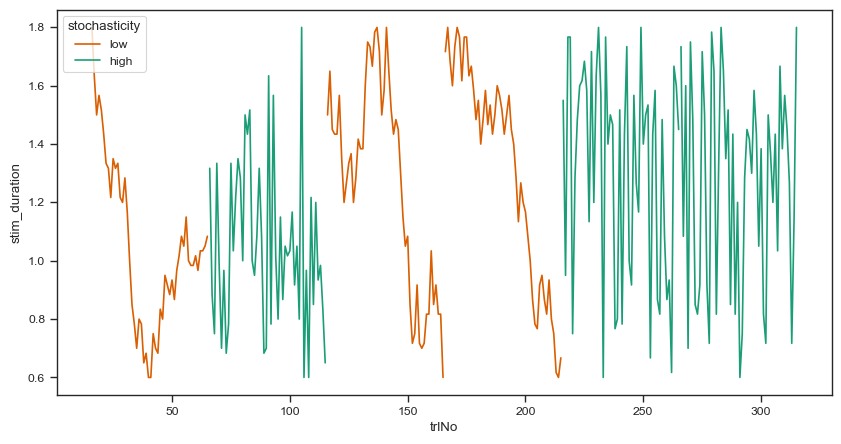

In [5]:
# sns
sns.set_theme(style='ticks', context='paper', rc={'figure.figsize': (10, 5)})
#sns.color_palette(palette='colorblind')
palette = sns.color_palette("Dark2")

# select a subset of rawdata (sub == 'ara27') for illustration
subdata = rawdata.query('sub == 36452')
# plot Duration as a function of trlNo, using different color for Volatility
# use color palette 'colorblind' from seaborn
#sns.set_palette('colorblind')
added_labels = set()

# Start plot
plt.figure()

# Plot lines by block and stochasticity
for _, block_df in subdata.groupby('blkNo'):
    for stochasticity_level, sub_df in block_df.groupby('stochasticity'):
        color = palette[0] if stochasticity_level == 'high' else palette[1]
        label = stochasticity_level if stochasticity_level not in added_labels else None
        sns.lineplot(
            x='trlNo',
            y='stim_duration',
            data=sub_df.sort_values('trlNo'),
            color=color,
            label=label
        )
        added_labels.add(stochasticity_level)

# Show legend with both labels
plt.legend(title='stochasticity')
plt.show()

In [6]:
mdata = rawdata.query('outlier == False').groupby(['sub', 'stochasticity','block_transition', 'stim_duration', 'blkNo']).agg(
    {'rep_err': ['mean', 'std']}).reset_index()
mdata.columns = ['sub', 'stochasticity', 'block_transition', 'stim_duration', 'blkNo', 'rep_err', 'rep_err_std']
#mdata

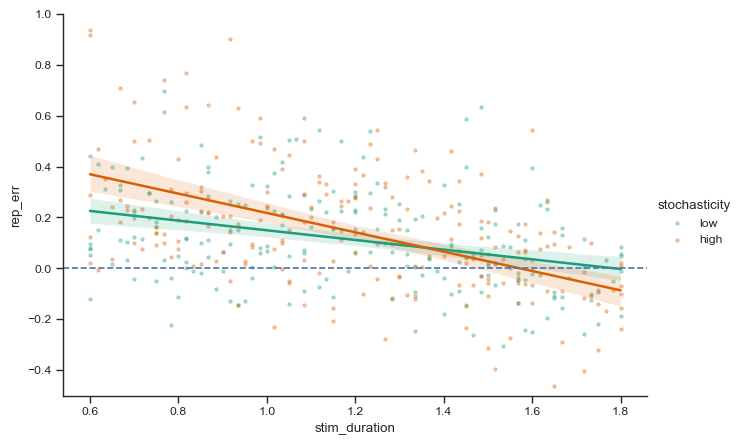

In [7]:
# visualize the mean reproduction error as a function of Duration
hue_order = ['low', 'high']
palette = sns.color_palette("Dark2", n_colors=len(hue_order))
ax = sns.lmplot(
    x='stim_duration', y='rep_err', hue='stochasticity', data=mdata, hue_order=hue_order, palette=palette, scatter_kws={'alpha': 0.3, 's': 5}, legend=True, height=4.5,
    aspect=1.5
)

# Add a dashed horizontal line at y=0
for ax1 in ax.axes.flat:
    ax1.axhline(0, ls='--')

# Set y-axis limits
plt.ylim(-0.5, 1.)

# Show plot
plt.show()

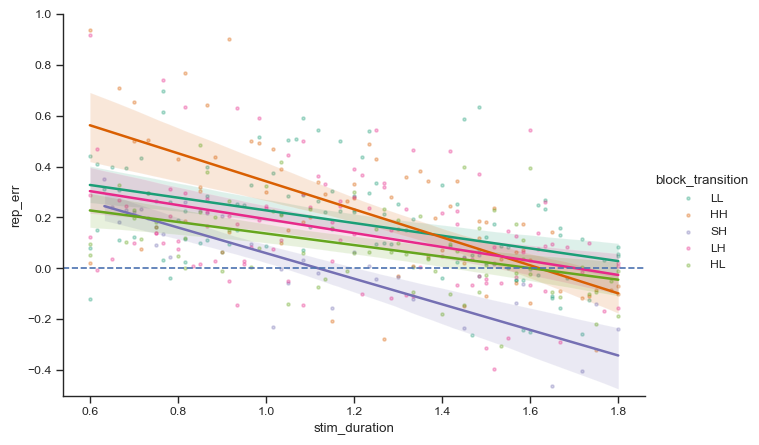

In [8]:
# visualize the mean reproduction error as a function of Duration
hue_order = ['LL', 'HH', 'SH', 'LH', 'HL']
palette = sns.color_palette("Dark2", n_colors=len(hue_order))

# Plot using lmplot with automatic legend
ax = sns.lmplot(
    x='stim_duration',
    y='rep_err',
    hue='block_transition',
    data=mdata,
    hue_order=hue_order,
    palette=palette,
    scatter_kws={'alpha': 0.3, 's': 5},
    legend=True,  # Let Seaborn do it
    height=4.5,
    aspect=1.5
)

# Add horizontal line at y=0
for ax1 in ax.axes.flat:
    ax1.axhline(0, ls='--')

# Set consistent y-axis limits
ax.set(ylim=(-0.5, 1.))

# Show plot
plt.show()

In [9]:
def plot_histograms(df, column='rpr_duration', groupby='sub', bins=30):
    subjects = df[groupby].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column]
        axes[i].hist(sub_data.dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{column} Histogram - {sub}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')

    # Remove unused subplots
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

def plot_qqplots(df, column='rpr_duration', groupby='sub'):
    subjects = df[groupby].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column].dropna()
        stats.probplot(sub_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot - {sub}')
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
        plt.tight_layout()
    plt.show()

Reproduction distribution grouped by participants, outliers included:

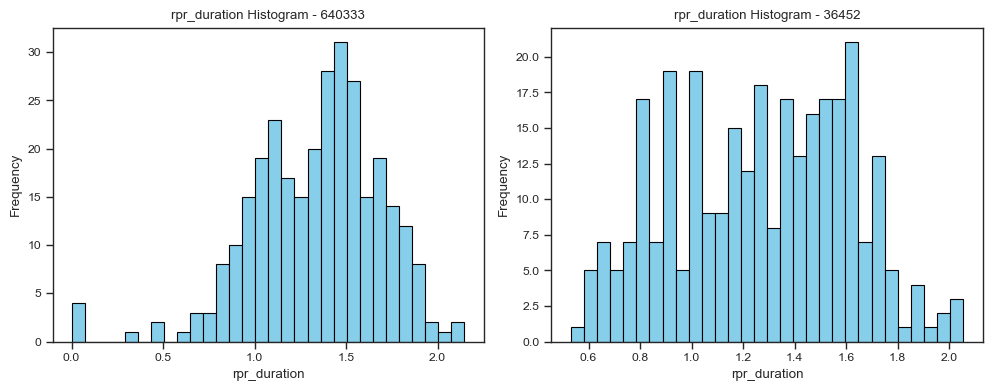

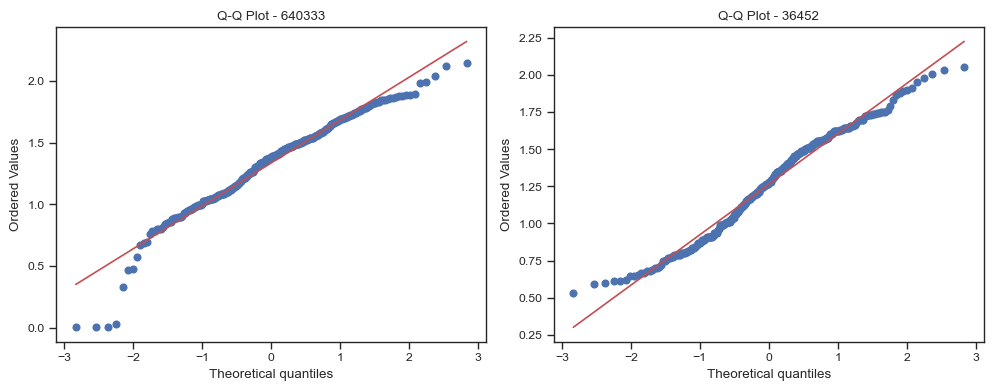

In [10]:
plot_histograms(rawdata)
plot_qqplots(rawdata)

Reproduction distribution grouped by participants, no outliers


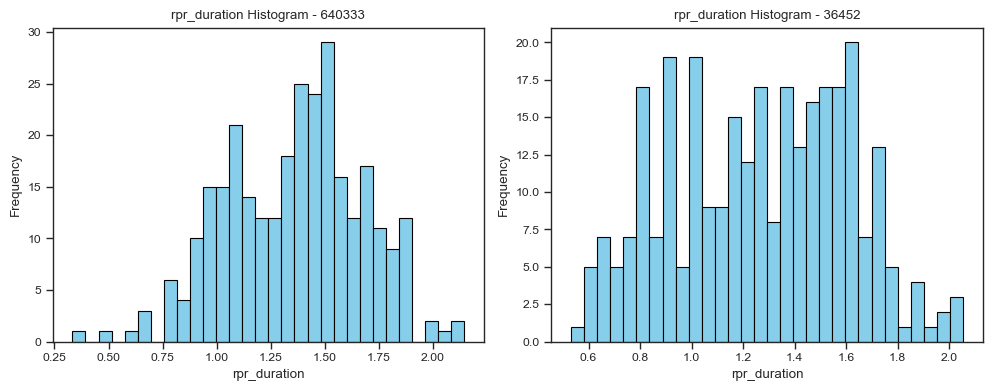

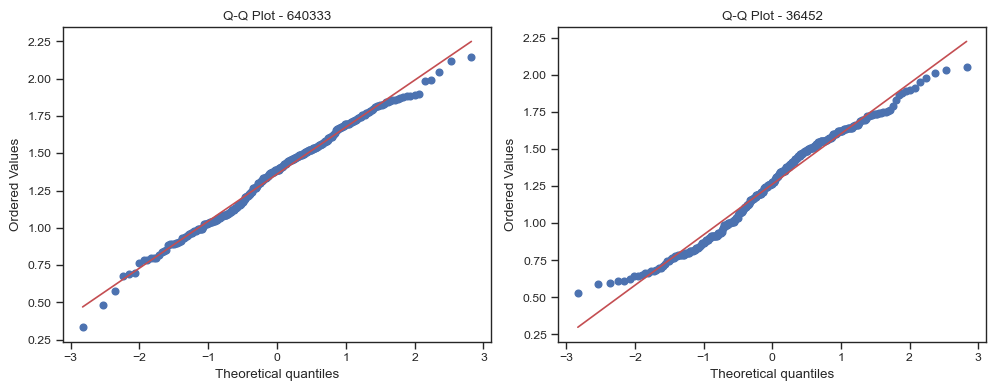

In [11]:
plot_histograms(rawdata.query('outlier == False'))
plot_qqplots(rawdata.query('outlier == False'))

Frequencies of block transitions, excluding the first blocks:

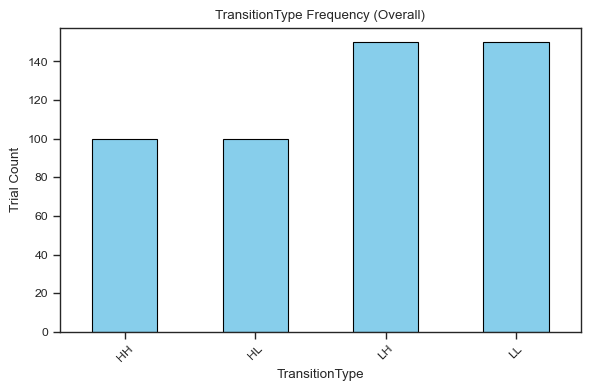

Overall Transition Type Proportions (%):
block_transition
HH    20.0 %
HL    20.0 %
LH    30.0 %
LL    30.0 %
Name: proportion, dtype: object


In [12]:
# TransitionType
transition_counts = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])]["block_transition"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
transition_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("TransitionType Frequency (Overall)")
plt.xlabel("TransitionType")
plt.ylabel("Trial Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
transition_prop = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])]["block_transition"].value_counts(normalize=True).sort_index()
print("Overall Transition Type Proportions (%):")
print((transition_prop * 100).round(2).astype(str) + " %")

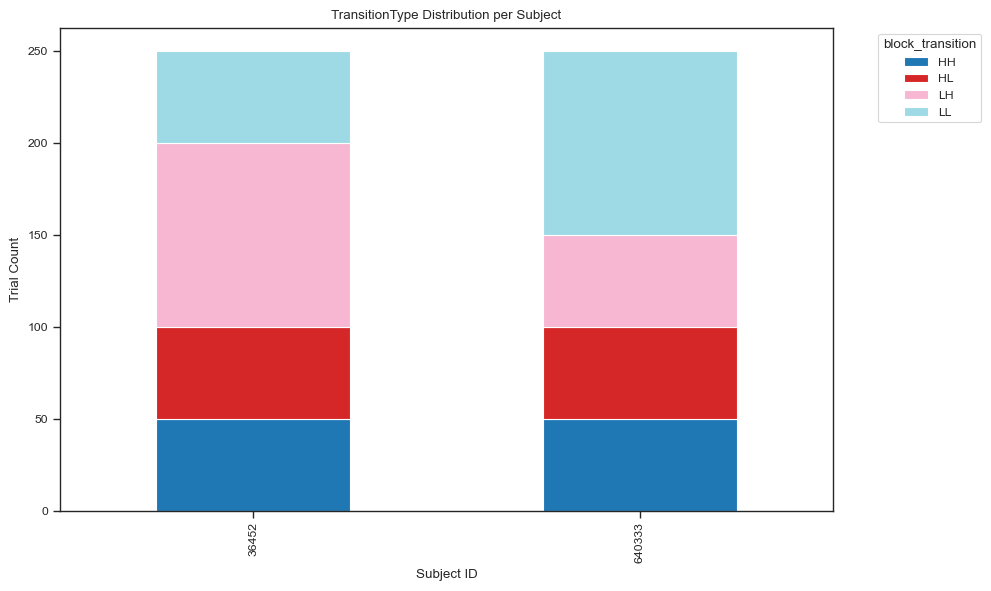

TransitionType proportions per subject (%):
block_transition      HH      HL      LH      LL
sub                                             
36452             20.0 %  20.0 %  40.0 %  20.0 %
640333            20.0 %  20.0 %  20.0 %  40.0 %


In [13]:
df_no_start_transition = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])]
transition_by_subject = df_no_start_transition.pivot_table( index="sub", columns="block_transition", aggfunc="size", fill_value=0)
transition_by_subject.plot( kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("TransitionType Distribution per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Trial Count")
plt.xticks(rotation=90)
plt.legend(title="block_transition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
transition_by_subject_prop = transition_by_subject.div(transition_by_subject.sum(axis=1), axis=0)
print("TransitionType proportions per subject (%):")
print((transition_by_subject_prop * 100).round(2).astype(str) + " %")

In [14]:
# reproduction bias
def balance_trials_min(df, condition_col="block_transition", group_col="sub"):
    balanced = []

    for sub_id, df_sub in df.groupby(group_col):
        cond_counts = df_sub[condition_col].value_counts()
        min_count = cond_counts.min()

        sub_balanced = []
        for cond, df_cond in df_sub.groupby(condition_col):
            sub_balanced.append(df_cond.sample(n=min_count, random_state=45))
        balanced.append(pd.concat(sub_balanced))

    return pd.concat(balanced).sort_values(by=[group_col, "trlNo"])


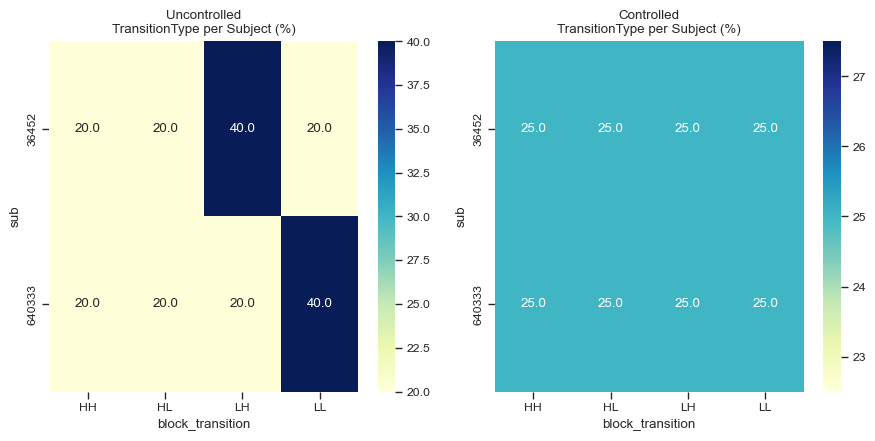

In [15]:
#dfb= balance_trials(df, max_per_cond=45)
# dfb means df balanced which takes the minimum trials of the 4 transition types
dfb= balance_trials_min(df_no_start_transition)
# subID × TransitionType
transition_by_subject_controlled = dfb.pivot_table(index="sub", columns="block_transition", aggfunc="size", fill_value=0)
# proportion_table unctrolled and controlled
ptuc = transition_by_subject.div(transition_by_subject.sum(axis=1), axis=0) * 100
ptc = transition_by_subject_controlled.div(transition_by_subject_controlled.sum(axis=1), axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
sns.heatmap(ptuc, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Uncontrolled\nTransitionType per Subject (%)")
sns.heatmap(ptc, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Controlled\nTransitionType per Subject (%)")
plt.tight_layout()
plt.show()

In [16]:
df = dfb
# reproduction bias for each subject
genRprBias = df.groupby('sub')['rep_err'].mean().reset_index()
print(genRprBias)
# Generallized Reproduction Bias
print('mean rpr Bias:', genRprBias['rep_err'].mean().round(3))
print('SE of rpr Bias:', genRprBias['rep_err'].sem().round(3))

      sub   rep_err
0   36452  0.071150
1  640333  0.210855
mean rpr Bias: 0.141
SE of rpr Bias: 0.07


In [17]:
# 1 reproduction CV（Coefficient of Variation）
RprCV = df.groupby('sub').agg({'rpr_duration': ['count', 'mean', 'std']}).reset_index()
RprCV.columns = ['sub', 'count', 'mean', 'std']
RprCV['cv'] = RprCV['std'] / RprCV['mean']
print(RprCV)
# overall CV
print('mean of overall CV:', RprCV['cv'].mean().round(3))
print('SE of overall CV:', RprCV['cv'].sem().round(3))
# t-test
import pingouin as pg
print(pg.ttest(RprCV['cv'], 0).round(3))

      sub  count      mean       std        cv
0   36452    200  1.329425  0.330339  0.248482
1  640333    200  1.395620  0.339794  0.243472
mean of overall CV: 0.246
SE of overall CV: 0.003
             T  dof alternative  p-val         CI95%  cohen-d   BF10  power
T-test  98.183    1   two-sided  0.006  [0.21, 0.28]   69.426  4.016    1.0


In [18]:
mCVPar = df.groupby(['sub', 'stim_duration']).agg({'rpr_duration': ['count', 'mean', 'std']}).reset_index()
mCVPar.columns = ['sub', 'stim_duration', 'count', 'mean', 'std']
mCVPar['cv'] = mCVPar['std'] / mCVPar['mean']


mCVAll = mCVPar.groupby('stim_duration').agg({'cv': ['count', 'mean', 'sem']
}).reset_index()
mCVAll.columns = ['stim_duration', 'count', 'mCV', 'seCV']

print(mCVAll)

    stim_duration  count       mCV      seCV
0           0.600      2  0.433316  0.263666
1           0.617      2  0.099013  0.060176
2           0.667      1  0.163359       NaN
3           0.683      2  0.242721  0.097947
4           0.700      2  0.206848  0.013901
..            ...    ...       ...       ...
64          1.734      1  0.006865       NaN
65          1.750      2  0.026710  0.022451
66          1.767      1  0.053863       NaN
67          1.784      1  0.014410       NaN
68          1.800      2  0.083753  0.014118

[69 rows x 4 columns]


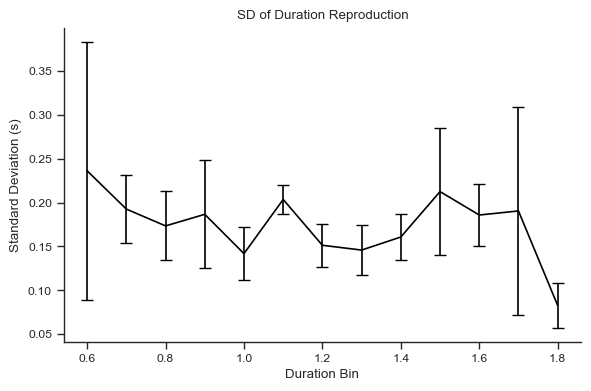

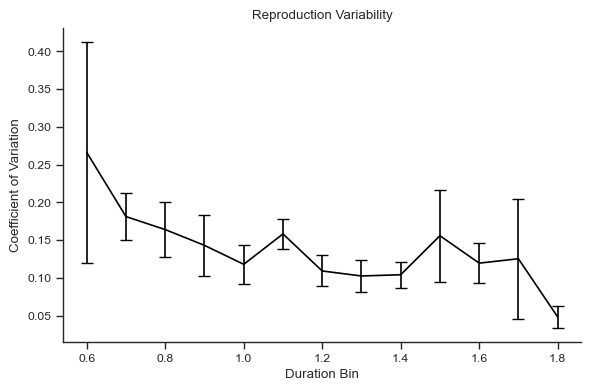

In [19]:
# plot SD vs current duration
# Round to nearest 0.2 seconds (adjust step as needed)
mCVPar['stim_bin'] = mCVPar['stim_duration'].round(1)

# Group and compute SD stats
mSDAll = mCVPar.groupby('stim_bin').agg({'std': ['count', 'mean', 'sem']}).reset_index()
mSDAll.columns = ['stim_bin', 'count', 'mSD', 'seSD']

# If you have mCVPar['cv'], do the same for CV stats
mCVAll = mCVPar.groupby('stim_bin').agg({'cv': ['mean', 'sem']}).reset_index()
mCVAll.columns = ['stim_bin', 'mCV', 'seCV']
fig, ax = plt.subplots(figsize=(6, 4))
plt.errorbar(x='stim_bin', y='mSD', yerr='seSD', data=mSDAll, color='black', capsize=4)
plt.xlabel('Duration Bin')
plt.ylabel('Standard Deviation (s)')
plt.title('SD of Duration Reproduction')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 4))
plt.errorbar(x='stim_bin', y='mCV', yerr='seCV', data=mCVAll, color='black', capsize=4)
plt.xlabel('Duration Bin')
plt.ylabel('Coefficient of Variation')
plt.title('Reproduction Variability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


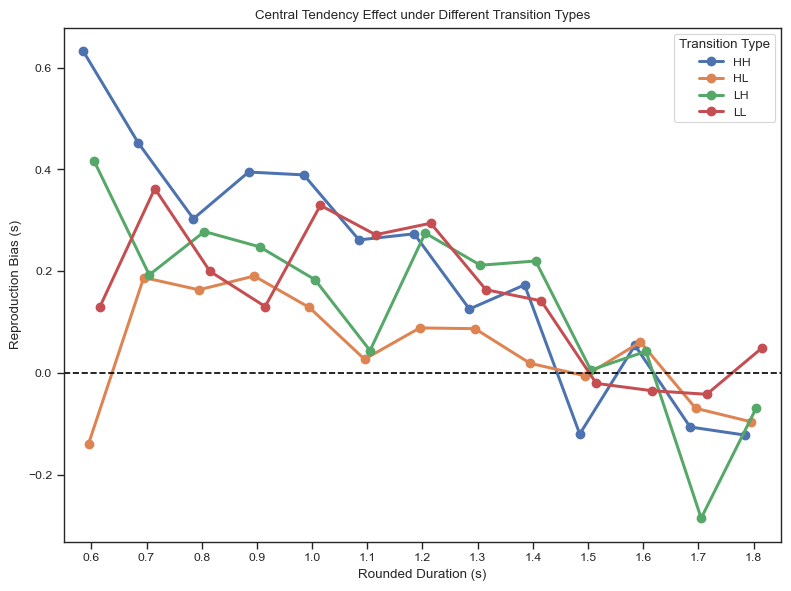

In [20]:
df['stim_bin'] = df['stim_duration'].round(1)
bias_grouped = df.groupby(['block_transition', 'stim_bin'])['rep_err'] \
    .agg(['count', 'mean', 'sem']).reset_index()
bias_grouped.columns = ['block_transition', 'stim_bin', 'count', 'mBias', 'seBias']

# Plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=bias_grouped,
              x='stim_bin', y='mBias', hue='block_transition',
              dodge=0.3, capsize=0.1, err_kws={'linewidth': 1.2})
plt.axhline(0, color='black', linestyle='--')
plt.title("Central Tendency Effect under Different Transition Types")
plt.xlabel("Rounded Duration (s)")
plt.ylabel("Reproduction Bias (s)")
plt.legend(title="Transition Type")
plt.tight_layout()
plt.show()

    preDuration_bin  count     mBias    seBias
0               0.6      2  0.074040  0.169183
1               0.7      2  0.123702  0.125369
2               0.8      2  0.214172  0.092136
3               0.9      2  0.120149  0.029065
4               1.0      2  0.200391  0.075776
5               1.1      2  0.101405  0.047280
6               1.2      2  0.100760  0.050760
7               1.3      2  0.163576  0.105710
8               1.4      2  0.138244  0.088356
9               1.5      2  0.074676  0.003676
10              1.6      2  0.224145  0.112645
11              1.7      2  0.021962  0.031962
12              1.8      2  0.119557  0.066157


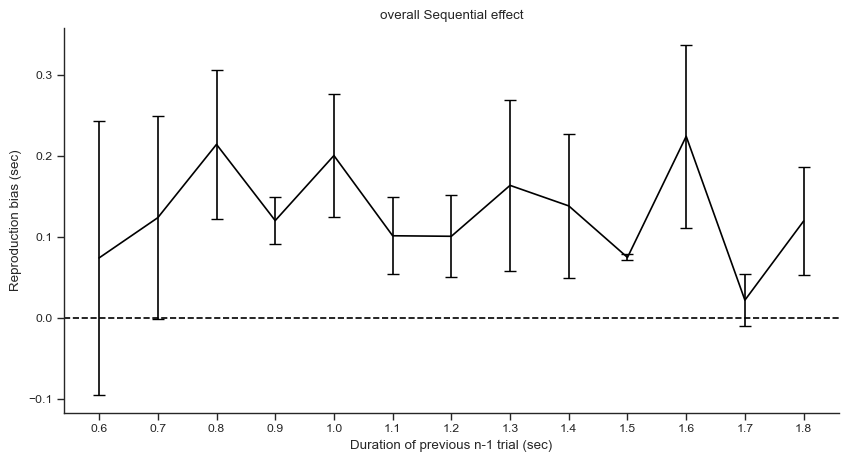

In [21]:
# overall Sequential effect (based on Reproduction Bias)
df['preDuration_bin'] = df['preDuration'].round(1)
mBiasPreDurPar = df.groupby(['sub','preDuration_bin']).rep_err.mean().reset_index()
mBiasPreDurAll = mBiasPreDurPar.groupby('preDuration_bin').\
    agg({"rep_err":["count","mean","sem"]}).reset_index()
mBiasPreDurAll.columns = ['preDuration_bin', 'count', 'mBias','seBias']
print(mBiasPreDurAll)

# rmANOVA: mean bias as a factor of pre-duration
#print('【rmANOVA of mean Bias on preDuration】')
#aov_bias_preDur = rmANOVA_gg_Long(mBiasPreDurPar, 'rep_err', ['preDuration'], 'subID')
#print(aov_bias_preDur)

# plot sequential effect
fig, ax = plt.subplots()
plt.errorbar(x='preDuration_bin', y='mBias', yerr='seBias', data=mBiasPreDurAll,
             color='black', capsize=4)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(mBiasPreDurAll.preDuration_bin)
plt.xlabel('Duration of previous n-1 trial (sec)')
plt.ylabel('Reproduction bias (sec)')
plt.title('overall Sequential effect')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [22]:
transition_slopes = []

# Unique transitions
transitions = ['LL', 'LH', 'HH', 'HL']

# Perform regression for each transition type
for transition in transitions:
    sub_df = rawdata[rawdata['block_transition'] == transition]

    if len(sub_df) >= 10:  # Ensure enough data
        X = sm.add_constant(sub_df['stim_duration'])
        y = sub_df['rpr_duration']
        model = sm.OLS(y, X).fit()
        slope = model.params['stim_duration']
        transition_slopes.append({
            'block_transition': transition,
            'slope': slope,
            'n_trials': len(sub_df)
        })
    else:
        transition_slopes.append({
            'block_transition': transition,
            'slope': None,
            'n_trials': len(sub_df)
        })

# Convert results to DataFrame
df_transition_slopes = pd.DataFrame(transition_slopes)
df_transition_slopes


,block_transition,slope,n_trials
0,LL,0.688884,150
1,LH,0.743159,150
2,HH,0.464836,100
3,HL,0.824087,100


1. LL, slope = 0.689
-> moderate central tendency, participants likely form an expectation about stimulus range, leading to some bias.
2. LH, slope = 0.465
-> slightly reduced compared to LL, a shift from predictable to unpredictable might make participants more attentive and accurate
3. HH, slope = 0.465
-> the strongest central tendency, participants likely rely on heuristics because the environment remains unpredictable.
4. HL, slope = 0.824
-> the most accurate reproduction, participants might relax in a more predictable context following unpredictability, improving performance.

In [23]:
from statsmodels.formula.api import ols

model = ols('rpr_duration ~ C(block_transition) + stim_duration', data=rawdata).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(block_transition),4.047345,5.0,14.908482,8.493003e-14
stim_duration,31.499616,1.0,580.147626,6.531980e-90
Residual,32.197447,593.0,NaN,NaN


There is a significant effect of block transition on reproduction accuracy.
As expected, stim_duration strongly predicts reproduction (a sanity check).

In [24]:
from itertools import combinations

transition_types = ['LL', 'LH', 'HH', 'HL']
pairwise_results = []

for a, b in combinations(transition_types, 2):
    group_a = rawdata[rawdata['block_transition'] == a]['rpr_duration']
    group_b = rawdata[rawdata['block_transition'] == b]['rpr_duration']
    t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)  # Welch's t-test
    pairwise_results.append({
        'Comparison': f'{a} vs {b}',
        't-statistic': t_stat,
        'p-value': p_val
    })

# Convert to DataFrame and display
df_pairwise = pd.DataFrame(pairwise_results)
df_pairwise

,Comparison,t-statistic,p-value
0,LL vs LH,0.796782,0.426213
1,LL vs HH,-1.017049,0.310239
2,LL vs HL,2.298751,0.022447
3,LH vs HH,-1.741322,0.082982
4,LH vs HL,1.511934,0.131936
5,HH vs HL,3.112555,0.002129


Above are the results of pairwise t-tests comparing reproduction accuracy across block transitions.